In [4]:
# Load Data
import pandas as pd

df = pd.read_csv("../temp_data/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
# Understand Data
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [7]:
# Data Cleaning
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

In [8]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [9]:
# Check Target Distribution
df['loan_status'].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [10]:
# Handle Missing Values
# Numerical columns
df.fillna(df.median(numeric_only=True), inplace=True)

In [11]:
# Categorical columns
df.fillna(df.mode().iloc[0], inplace=True)

In [12]:
# reate New Features
df['loan_income_ratio'] = df['loan_amnt'] / df['person_income']
df['income_per_person_age'] = df['person_income'] / df['person_age']

In [13]:
# Convert Categorical → Numeric
df = pd.get_dummies(df, drop_first=True)

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 VERY IMPORTANT
)

In [15]:
# VERIFY SPLIT 
print("Train:\n", y_train.value_counts())
print("Test:\n", y_test.value_counts())

Train:
 loan_status
0    20261
1     5671
Name: count, dtype: int64
Test:
 loan_status
0    5066
1    1418
Name: count, dtype: int64


In [16]:
# ENCODING 

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align both datasets 
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [18]:
# APPLY SMOTE AGAIN
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

c:\Users\pradn\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\pradn\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\pradn\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pradn\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [19]:
# SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [20]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [21]:
# MODEL TRAINING (XGBoost)
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss')

model.fit(X_train_pca, y_train_res)

y_pred = model.predict(X_test_pca)

In [22]:
# EVALUATION
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5066
           1       0.82      0.70      0.76      1418

    accuracy                           0.90      6484
   macro avg       0.87      0.83      0.85      6484
weighted avg       0.90      0.90      0.90      6484

ROC-AUC: 0.8294711500715242


In [23]:
import joblib

joblib.dump(model, "../models/model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(pca, "../models/pca.pkl")
joblib.dump(imputer, "../models/imputer.pkl")
joblib.dump(X.columns, "../models/columns.pkl")   # ✅ ADD THIS

['../models/columns.pkl']

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Predict on test data
y_pred = model.predict(X_test_pca)

# Step 2: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Step 3: Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 4: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9017581739666872

Confusion Matrix:
[[4853  213]
 [ 424  994]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5066
           1       0.82      0.70      0.76      1418

    accuracy                           0.90      6484
   macro avg       0.87      0.83      0.85      6484
weighted avg       0.90      0.90      0.90      6484



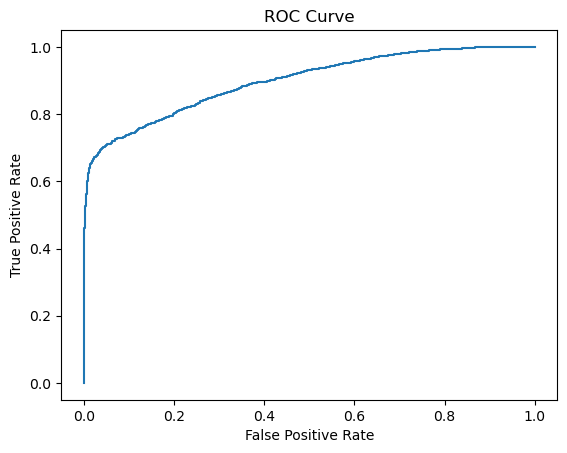

ROC-AUC Score: 0.8977263172665247


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_pca)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))